## `make_results.ipynb`

-----------------------

This notebook collates the results and plots them. Most methods are accessible in `results_methods.py`

In [1]:
import numpy as np 
import fitsio as fio 
import pandas as pd 
import importlib
import matplotlib.pyplot as plt

from pathlib import Path
from pycorr import TwoPointEstimator
from scipy.integrate import simpson

import src.statistics.results_methods as resm
import src.statistics.corrutils as cu
import src.statistics.corrfiles as cf

# Methods:
----------

We use the [Euclid](https://arxiv.org/pdf/2208.10503) approach (derived from Schmidt+2013):

$n_p(z_i)=\frac{\omega_{\rm{sp}}(r, z_i)}{\Delta z\sqrt{\omega_{\rm{ss}}(r, z_i)\omega_{\rm{pp}}(r, z_i)}}$

for each DESI tracer where we have information.


$n_{p, j}(z_i)=\frac{\omega_{\rm{sp}}(r, z_i)}{\Delta z\sqrt{b_s(z)\omega_{\rm{ss}}(r, z_i)b_p(z)\omega_{\rm{pp}, j}(r)}}$

In [8]:
importlib.reload(resm)
allsep, allcorr, allcov = resm.wpp(path='./results/autos_j64_ns256_zbin')

Combine ratios per MOC: [0.58427033 0.07539333 0.23266888 0.10766453]


In [21]:
importlib.reload(resm)
ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/results_v1/')
desc = 'j64_ns256'
path_dictionary = {
    'HSC' : ROOT / f'autos_{desc}',
    'DESI_NGC' : ROOT / f'autos_{desc}_NGC',
    'DESI_SGC' : ROOT / f'autos_{desc}_SGC',
    'DESIxHSC' : ROOT.parent / 'results' / f'cross_{desc}_zbin',
}
for v in path_dictionary.values():
    assert v.is_dir(), f"Path {v} does not exist as a directory. Please check the path."

In [68]:
importlib.reload(resm)
tracer = 'QSO'
nz = []
for i in range(1, 5):
    print(f"Computing npz for tracer {tracer} and tomo bin {i}")
    nz.append(
        resm.full_npz_tomo(
            path_dictionary=path_dictionary,
            tracer=tracer,
            tomo_bin=i,
            )
    )

Computing npz for tracer QSO and tomo bin 1
B : 0.4810, 1.6965, diff : -0.5190, 0.6965, num : 0.1620, num_no_b : 0.1793
B : 0.4471, 1.8423, diff : -0.5529, 0.8423, num : 0.1568, num_no_b : 0.1728
B : 0.4176, 1.9987, diff : -0.5824, 0.9987, num : 0.1780, num_no_b : 0.1948
B : 0.3918, 2.1658, diff : -0.6082, 1.1658, num : 0.1808, num_no_b : 0.1963
B : 0.3689, 2.3436, diff : -0.6311, 1.3436, num : 0.1934, num_no_b : 0.2080
B : 0.3486, 2.5320, diff : -0.6514, 1.5320, num : 0.1801, num_no_b : 0.1917
B : 0.3304, 2.7310, diff : -0.6696, 1.7310, num : 0.1932, num_no_b : 0.2034
B : 0.3140, 2.9408, diff : -0.6860, 1.9408, num : 0.2371, num_no_b : 0.2467
B : 0.2992, 3.1612, diff : -0.7008, 2.1612, num : 0.2210, num_no_b : 0.2273
B : 0.2857, 3.3923, diff : -0.7143, 2.3923, num : 0.2511, num_no_b : 0.2550
B : 0.2734, 3.6340, diff : -0.7266, 2.6340, num : 0.2540, num_no_b : 0.2548
B : 0.2621, 3.8864, diff : -0.7379, 2.8864, num : 0.2747, num_no_b : 0.2722
B : 0.2517, 4.1495, diff : -0.7483, 3.1495, 

(0.8, 2.95)

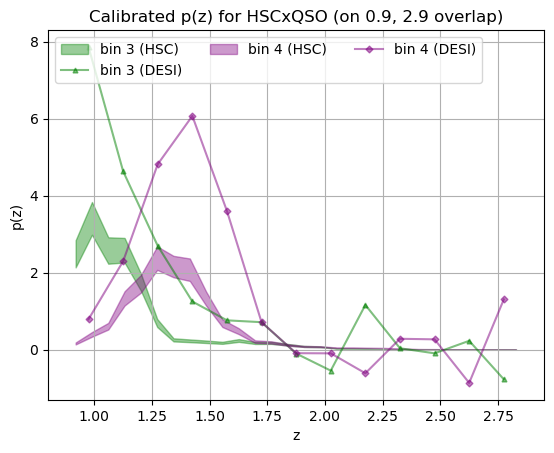

In [67]:
bins_tracer = cf.CorrFileReader(
    path_dictionary['DESI_NGC'],
    ).get_bins(tracer)
bins_hsc = cf.CorrFileReader(
    path_dictionary['HSC'],
    ).get_bins('HSC')
colors = ['red', 'blue', 'green', 'purple']
markers = ['x', 's', '^', 'D']
zval = bins_tracer[:-1] + np.diff(bins_tracer) / 2

tomo_bin_dnnz = np.loadtxt('hsc_pz/data/tomographic_binning_dnnz.dat')

mask = (tomo_bin_dnnz[:, 0] >= min(bins_tracer)) & (tomo_bin_dnnz[:, 0] <= max(bins_tracer))
mids = tomo_bin_dnnz[mask, 0]

dnnz_list = []
mu_list = []
cov_list = []
ids_to_skip = []
range_tracer = [bins_tracer[0], bins_tracer[-1]]
for i in range(4):
    if max(range_tracer[0], bins_hsc[i]) > min(range_tracer[1], bins_hsc[i+1]):
        ids_to_skip.append(i)

for i in range(4):
    if i in ids_to_skip:
        continue
    dnnz, mu, cov = resm.hsc_dnnz_error(tomo_bin_dnnz[mask, i+1], mids)

    plt.fill_between(
        mids, 
        np.percentile(dnnz, 16, axis=0), 
        np.percentile(dnnz, 84, axis=0), 
        color=colors[i], 
        label=f'bin {i+1} (HSC)',
        alpha=0.4
        )
    plt.plot(
        zval, 
        nz[i],#/simpson(nz[i], x=zval), 
        marker=markers[i], 
        markersize=3.5, 
        linestyle='-',  
        alpha=0.5,
        color=colors[i],
        label=f'bin {i+1} (DESI)'
        )
    
plt.xlabel('z')
plt.ylabel('p(z)')
plt.grid()
plt.legend(fontsize=10, ncols=3, loc='upper left')
plt.title(f'Calibrated p(z) for HSCx{tracer} (on {min(bins_tracer):.1f}, {max(bins_tracer):.1f} overlap)')
plt.xlim(min(bins_tracer)-0.1, max(bins_tracer)+0.1)
#plt.ylim(-1, 7.5)

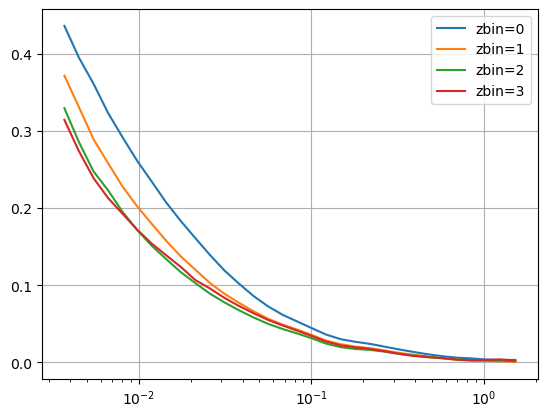

In [28]:
import matplotlib.pyplot as plt
for i in range(4):
    plt.plot(allsep[i], allcorr[i], label=f'zbin={i}')
plt.legend()
plt.xscale('log')
plt.grid()